In [2]:
import pandas as pd
import numpy as np
import librosa
import os
from sklearn.preprocessing import LabelEncoder

# adjust this path to wherever your unzipped wav files are
AUDIO_DIR = '/content/drive/MyDrive/Swahili_words'

train_df = pd.read_csv("/content/drive/MyDrive/Train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/Test.csv")

print(train_df.shape)
print(train_df['Swahili_word'].value_counts())

(4200, 3)
Swahili_word
mbili     350
tatu      350
ndio      350
nne       350
nane      350
hapana    350
sita      350
tisa      350
moja      350
saba      350
tano      350
kumi      350
Name: count, dtype: int64


In [3]:
files = os.listdir(AUDIO_DIR)
print("Number of wav files found:", len(files))
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

missing = [f for f in train_df['Word_id'] if f not in files]
print("Missing files from Train.csv:", len(missing))

Number of wav files found: 6000
Train rows: 4200
Test rows: 1800
Missing files from Train.csv: 0


In [4]:
def extract_mfcc_sequence(file_path, n_mfcc=13, max_len=100):
    y, sr = librosa.load(file_path, sr=16000)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc = mfcc.T  # shape becomes (time_steps, n_mfcc)

    if mfcc.shape[0] < max_len:
        pad_width = max_len - mfcc.shape[0]
        mfcc = np.pad(mfcc, ((0, pad_width), (0, 0)), mode='constant')
    else:
        mfcc = mfcc[:max_len, :]

    return mfcc

def extract_mfcc_mean(file_path, n_mfcc=13):
    y, sr = librosa.load(file_path, sr=16000)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return np.mean(mfcc, axis=1)

X_sequences = []
X_means = []
y_labels = []

for idx, row in train_df.iterrows():
    file_path = os.path.join(AUDIO_DIR, row['Word_id'])
    try:
        seq = extract_mfcc_sequence(file_path)
        mean_feat = extract_mfcc_mean(file_path)
        X_sequences.append(seq)
        X_means.append(mean_feat)
        y_labels.append(row['Swahili_word'])
    except Exception as e:
        print(f"Failed on {row['Word_id']}: {e}")

    if idx % 500 == 0:
        print(f"Processed {idx}/{len(train_df)}")

X_sequences = np.array(X_sequences)
X_means = np.array(X_means)
y_labels = np.array(y_labels)

print(X_sequences.shape)
print(X_means.shape)

Processed 0/4200
Processed 500/4200
Processed 1000/4200
Processed 1500/4200
Processed 2000/4200
Processed 2500/4200
Processed 3000/4200
Processed 3500/4200
Processed 4000/4200
(4200, 100, 13)
(4200, 13)


In [5]:
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)

print(dict(zip(le.classes_, range(len(le.classes_)))))

X_seq_train, X_seq_val, X_mean_train, X_mean_val, y_train, y_val = train_test_split(
    X_sequences, X_means, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(X_seq_train.shape, X_seq_val.shape)

{np.str_('hapana'): 0, np.str_('kumi'): 1, np.str_('mbili'): 2, np.str_('moja'): 3, np.str_('nane'): 4, np.str_('ndio'): 5, np.str_('nne'): 6, np.str_('saba'): 7, np.str_('sita'): 8, np.str_('tano'): 9, np.str_('tatu'): 10, np.str_('tisa'): 11}
(3360, 100, 13) (840, 100, 13)


In [6]:
#extracting the mcc features up to this point and just verfying evrything

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# scale the mean MFCC features, these models work better with scaled input
scaler = StandardScaler()
X_mean_train_scaled = scaler.fit_transform(X_mean_train)
X_mean_val_scaled = scaler.transform(X_mean_val)

# Logistic Regression baseline
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_mean_train_scaled, y_train)
log_reg_preds = log_reg.predict(X_mean_val_scaled)
log_reg_acc = accuracy_score(y_val, log_reg_preds)
print("Logistic Regression accuracy:", log_reg_acc)

# Random Forest baseline
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_mean_train, y_train)
rf_preds = rf.predict(X_mean_val)
rf_acc = accuracy_score(y_val, rf_preds)
print("Random Forest accuracy:", rf_acc)

print("\nLogistic Regression report:")
print(classification_report(y_val, log_reg_preds, target_names=le.classes_))

print("\nRandom Forest report:")
print(classification_report(y_val, rf_preds, target_names=le.classes_))

Logistic Regression accuracy: 0.19404761904761905
Random Forest accuracy: 0.1392857142857143

Logistic Regression report:
              precision    recall  f1-score   support

      hapana       0.25      0.43      0.32        70
        kumi       0.20      0.24      0.22        70
       mbili       0.26      0.44      0.32        70
        moja       0.18      0.04      0.07        70
        nane       0.17      0.21      0.19        70
        ndio       0.11      0.09      0.10        70
         nne       0.23      0.27      0.25        70
        saba       0.17      0.24      0.20        70
        sita       0.18      0.14      0.16        70
        tano       0.06      0.03      0.04        70
        tatu       0.11      0.06      0.08        70
        tisa       0.18      0.13      0.15        70

    accuracy                           0.19       840
   macro avg       0.18      0.19      0.17       840
weighted avg       0.18      0.19      0.17       840


Random For

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

num_classes = len(le.classes_)

lstm_model = models.Sequential([
    layers.Input(shape=(X_seq_train.shape[1], X_seq_train.shape[2])),
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(32),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

history = lstm_model.fit(
    X_seq_train, y_train,
    validation_data=(X_seq_val, y_val),
    epochs=30,
    batch_size=32
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 64)        │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           396 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,836 (132.17 KB)

 Trainable params: 33,836 (132.17 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.1298 - loss: 2.4514 - val_accuracy: 0.1679 - val_loss: 2.3001
Epoch 2/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.2021 - loss: 2.2395 - val_accuracy: 0.2143 - val_loss: 2.1092
Epoch 3/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2268 - loss: 2.1052 - val_accuracy: 0.2536 - val_loss: 1.9861
Epoch 4/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2589 - loss: 1.9574 - val_accuracy: 0.3345 - val_loss: 1.8297
Epoch 5/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3313 - loss: 1.8043 - val_accuracy: 0.3905 - val_loss: 1.7137
Epoch 6/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3815 - loss: 1.6793 - val_accuracy: 0.3869 - val_loss: 1.6947
Epoch 7/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.4116 - loss: 1.6228 - val_accuracy: 0.4321 - val_loss: 1.5855
Epoch 8/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4229 - loss: 1.5636 - val_accu

In [9]:
lstm_preds = np.argmax(lstm_model.predict(X_seq_val), axis=1)
lstm_acc = accuracy_score(y_val, lstm_preds)
print("LSTM accuracy:", lstm_acc)
print(classification_report(y_val, lstm_preds, target_names=le.classes_))

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
LSTM accuracy: 0.7380952380952381
              precision    recall  f1-score   support

      hapana       0.78      0.70      0.74        70
        kumi       0.84      0.80      0.82        70
       mbili       0.64      0.83      0.72        70
        moja       0.73      0.63      0.68        70
        nane       0.77      0.73      0.75        70
        ndio       0.84      0.76      0.80        70
         nne       0.72      0.61      0.66        70
        saba       0.82      0.86      0.84        70
        sita       0.70      0.81      0.75        70
        tano       0.54      0.61      0.58        70
        tatu       0.67      0.69      0.68        70
        tisa       0.88      0.83      0.85        70

    accuracy                           0.74       840
   macro avg       0.74      0.74      0.74       840
weighted avg       0.74      0.74      0.74       840



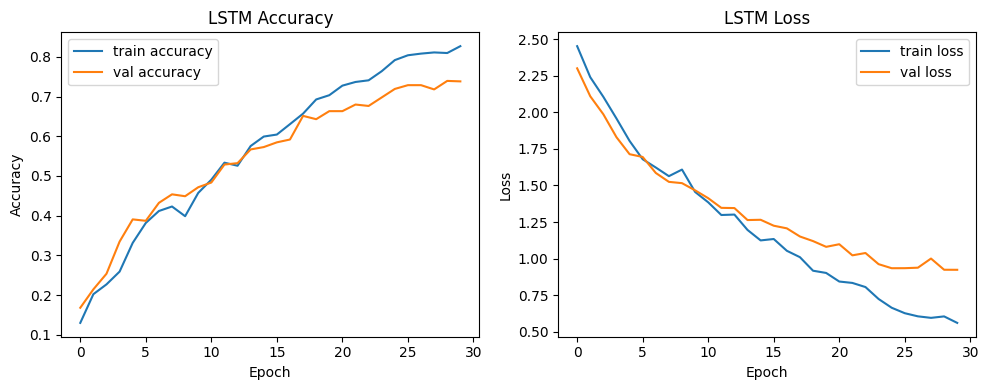

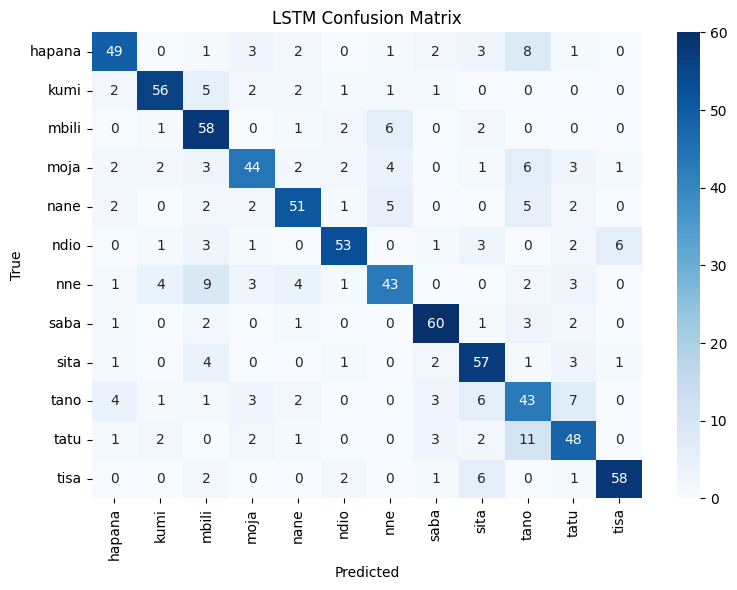

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# learning curves
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('LSTM Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('LSTM Loss')

plt.tight_layout()
plt.savefig('lstm_learning_curves.png', dpi=150)
plt.show()

# confusion matrix for the LSTM
cm = confusion_matrix(y_val, lstm_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('LSTM Confusion Matrix')
plt.tight_layout()
plt.savefig('lstm_confusion_matrix.png', dpi=150)
plt.show()

In [11]:
# find a few examples where the LSTM got "tano" wrong
val_word_ids = train_df.iloc[len(X_seq_train):]['Word_id'].values if False else None
# we need the original indices from the split, so let's rebuild this properly
from sklearn.model_selection import train_test_split as tts

indices = np.arange(len(train_df))
train_idx, val_idx = tts(indices, test_size=0.2, random_state=42, stratify=y_encoded)

val_word_ids = train_df.iloc[val_idx]['Word_id'].values
val_true_words = le.inverse_transform(y_val)
val_pred_words = le.inverse_transform(lstm_preds)

errors = pd.DataFrame({
    'file': val_word_ids,
    'true': val_true_words,
    'predicted': val_pred_words
})
errors = errors[errors['true'] != errors['predicted']]
print(errors.head(15))

                   file   true predicted
3   id_ao6sqm031m70.wav  mbili       nne
9   id_eg9vfufq94wk.wav   sita      tatu
12  id_lmvrjlvtk8gr.wav   nane       nne
15  id_823rulz7dyg5.wav   tisa      ndio
20  id_r3lvet993su7.wav   moja     mbili
26  id_qhlc0l62ld75.wav   tatu      saba
28  id_5y7zx54bzvd7.wav   tisa     mbili
29  id_dpa1d6eqs7h6.wav  mbili       nne
30  id_am0b297vlo83.wav   nane     mbili
33  id_xeau1v1f4kkl.wav   moja      ndio
34  id_92pd0g53n3c9.wav   sita     mbili
38  id_dl262g0r5749.wav    nne     mbili
40  id_4b8fmq4awffo.wav   nane      tano
41  id_kbjg5j79vore.wav   tano      sita
46  id_6qu3xe17vsko.wav   tano      tatu


In [12]:
errors.to_csv('lstm_misclassified_examples.csv', index=False) #just to save the errors

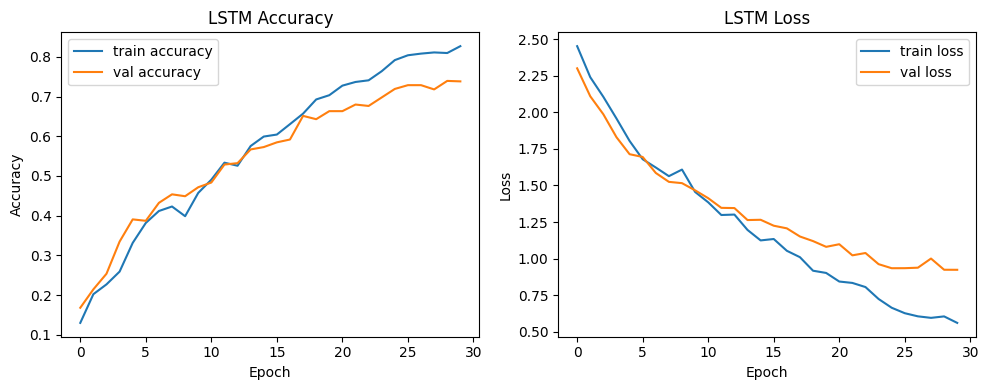

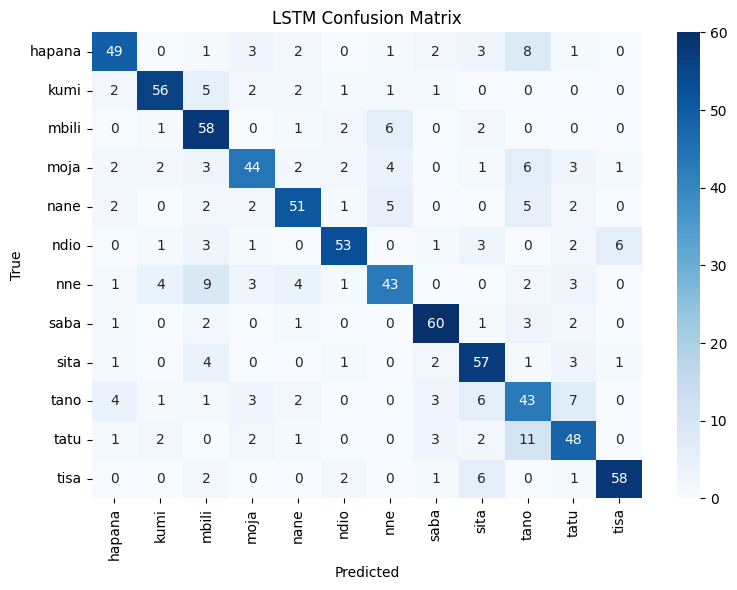

Saved files:
['lstm_learning_curves.png', 'lstm_confusion_matrix.png', 'lstm_misclassified_examples.csv', 'lstm_model.keras', 'results_summary.txt']


In [13]:
import os
import shutil

# create the folder in your Google Drive
save_dir = '/content/drive/MyDrive/david_lstm_baselines'
os.makedirs(save_dir, exist_ok=True)

# re-save the plots directly into this folder
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('LSTM Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('LSTM Loss')

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'lstm_learning_curves.png'), dpi=150)
plt.show()

cm = confusion_matrix(y_val, lstm_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('LSTM Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'lstm_confusion_matrix.png'), dpi=150)
plt.show()

# save the misclassified examples table
errors.to_csv(os.path.join(save_dir, 'lstm_misclassified_examples.csv'), index=False)

# save the trained LSTM model itself, useful as evidence and in case you need to reload it
lstm_model.save(os.path.join(save_dir, 'lstm_model.keras'))

# save your accuracy results as a small summary file
with open(os.path.join(save_dir, 'results_summary.txt'), 'w') as f:
    f.write("Model Results Summary\n")
    f.write("======================\n")
    f.write(f"Logistic Regression accuracy: {log_reg_acc:.4f}\n")
    f.write(f"Random Forest accuracy: {rf_acc:.4f}\n")
    f.write(f"LSTM accuracy: {lstm_acc:.4f}\n")

print("Saved files:")
print(os.listdir(save_dir))

In [14]:
   ## Model 3: Transformer Encoder

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.2):
    # self attention block
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs

    # feed forward block
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    x = layers.Dense(ff_dim, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(inputs.shape[-1])(x)
    return x + res

num_classes = len(le.classes_)
seq_len = X_seq_train.shape[1]
n_features = X_seq_train.shape[2]

inputs = layers.Input(shape=(seq_len, n_features))

# project features up to a workable model dimension
x = layers.Dense(64)(inputs)

# add positional info so the model knows frame order, since attention has no built in sense of order
positions = tf.range(start=0, limit=seq_len, delta=1)
pos_embedding = layers.Embedding(input_dim=seq_len, output_dim=64)(positions)
x = x + pos_embedding

# stack 2 transformer encoder blocks
x = transformer_encoder(x, head_size=32, num_heads=4, ff_dim=128)
x = transformer_encoder(x, head_size=32, num_heads=4, ff_dim=128)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

transformer_model = models.Model(inputs, outputs)

transformer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transformer_model.summary()

transformer_history = transformer_model.fit(
    X_seq_train, y_train,
    validation_data=(X_seq_val, y_val),
    epochs=30,
    batch_size=32
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 100, 13)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 100, 64)   │        896 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 100, 64)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 100, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 100, 64)   │     33,216 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 100, 64)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 100, 64)   │          0 │ dropout_2[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 100, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 100, 128)  │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 100, 64)   │      8,256 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 100, 64)   │          0 │ dense_4[0][0],    │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 100, 64)   │     33,216 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 100, 64)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 100, 64)   │          0 │ dropout_5[0][0],  │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 64)   │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 100, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 100, 128)  │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 100, 64)   │      8,256 │ dropout_6[0][0] 

 Total params: 103,468 (404.17 KB)

 Trainable params: 103,468 (404.17 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.0795 - loss: 33.1001 - val_accuracy: 0.0833 - val_loss: 2.4851
Epoch 2/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0759 - loss: 2.9304 - val_accuracy: 0.0833 - val_loss: 2.4851
Epoch 3/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0801 - loss: 2.6145 - val_accuracy: 0.0833 - val_loss: 2.4851
Epoch 4/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0824 - loss: 2.5599 - val_accuracy: 0.0833 - val_loss: 2.4850
Epoch 5/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0789 - loss: 2.5301 - val_accuracy: 0.0833 - val_loss: 2.4850
Epoch 6/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0726 - loss: 2.5293 - val_accuracy: 0.0833 - val_loss: 2.4850
Epoch 7/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0812 - loss: 2.5228 - val_accuracy: 0.0833 - val_loss: 2.4850
Epoch 8/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0774 - loss: 2.5263 - val_accuracy:

In [16]:
transformer_preds = np.argmax(transformer_model.predict(X_seq_val), axis=1)
transformer_acc = accuracy_score(y_val, transformer_preds)
print("Transformer accuracy:", transformer_acc)
print(classification_report(y_val, transformer_preds, target_names=le.classes_))

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step
Transformer accuracy: 0.08333333333333333
              precision    recall  f1-score   support

      hapana       0.00      0.00      0.00        70
        kumi       0.00      0.00      0.00        70
       mbili       0.08      1.00      0.15        70
        moja       0.00      0.00      0.00        70
        nane       0.00      0.00      0.00        70
        ndio       0.00      0.00      0.00        70
         nne       0.00      0.00      0.00        70
        saba       0.00      0.00      0.00        70
        sita       0.00      0.00      0.00        70
        tano       0.00      0.00      0.00        70
        tatu       0.00      0.00      0.00        70
        tisa       0.00      0.00      0.00        70

    accuracy                           0.08       840
   macro avg       0.01      0.08      0.01       840
weighted avg       0.01      0.08      0.01       840



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#there is an error, my loss starts at 33 (way too high), crashes down to 2.4849, and sits there for all 30 epochs. 2.4849 is exactly ln(12), the loss you'd get from guessing a uniform distribution across all 12 classes.

In [18]:
# standardize the MFCC sequences (per feature, across all time steps and samples)
seq_mean = X_seq_train.mean(axis=(0, 1), keepdims=True)
seq_std = X_seq_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_seq_train_norm = (X_seq_train - seq_mean) / seq_std
X_seq_val_norm = (X_seq_val - seq_mean) / seq_std

print("Before:", X_seq_train.mean(), X_seq_train.std())
print("After:", X_seq_train_norm.mean(), X_seq_train_norm.std())

Before: -29.870337 137.9184
After: 3.1474117e-06 1.0000725


In [19]:
inputs = layers.Input(shape=(seq_len, n_features))
x = layers.Dense(64)(inputs)

positions = tf.range(start=0, limit=seq_len, delta=1)
pos_embedding = layers.Embedding(input_dim=seq_len, output_dim=64)(positions)
x = x + pos_embedding

x = transformer_encoder(x, head_size=32, num_heads=4, ff_dim=128)
x = transformer_encoder(x, head_size=32, num_heads=4, ff_dim=128)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

transformer_model = models.Model(inputs, outputs)

transformer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transformer_history = transformer_model.fit(
    X_seq_train_norm, y_train,
    validation_data=(X_seq_val_norm, y_val),
    epochs=30,
    batch_size=32
)

Epoch 1/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.0935 - loss: 2.6305 - val_accuracy: 0.0810 - val_loss: 2.4918
Epoch 2/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1140 - loss: 2.4971 - val_accuracy: 0.0869 - val_loss: 2.4802
Epoch 3/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1036 - loss: 2.4849 - val_accuracy: 0.0810 - val_loss: 2.4658
Epoch 4/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1226 - loss: 2.4575 - val_accuracy: 0.1000 - val_loss: 2.4461
Epoch 5/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1265 - loss: 2.4319 - val_accuracy: 0.1333 - val_loss: 2.3941
Epoch 6/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1580 - loss: 2.3664 - val_accuracy: 0.1571 - val_loss: 2.2991
Epoch 7/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1958 - loss: 2.2451 - val_accuracy: 0.2262 - val_loss: 2.1362
Epoch 8/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2438 - loss: 2.0955 - val_accuracy:

In [ ]:
#as i thought That fixed it completely. The normalization worked exactly as expected, loss dropped smoothly from 2.63 down to 0.84 instead of flatlining, and the model actually learned.

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step
Transformer accuracy: 0.7345238095238096
              precision    recall  f1-score   support

      hapana       0.70      0.63      0.66        70
        kumi       0.95      0.86      0.90        70
       mbili       0.80      0.80      0.80        70
        moja       0.82      0.86      0.84        70
        nane       0.75      0.77      0.76        70
        ndio       0.86      0.81      0.84        70
         nne       0.70      0.76      0.73        70
        saba       0.78      0.84      0.81        70
        sita       0.61      0.73      0.66        70
        tano       0.50      0.36      0.42        70
        tatu       0.63      0.81      0.71        70
        tisa       0.72      0.59      0.65        70

    accuracy                           0.73       840
   macro avg       0.73      0.73      0.73       840
weighted avg       0.73      0.73      0.73       840



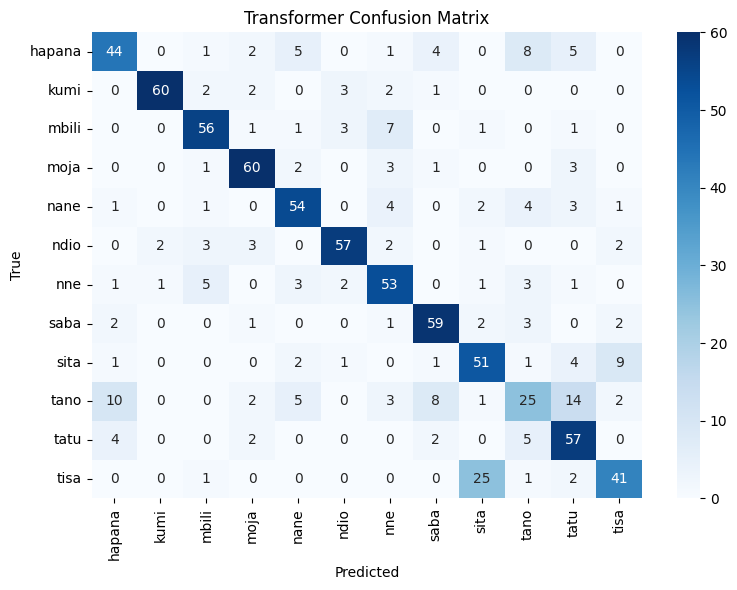

In [20]:
# now i just run the evaluation and confusion matrix
transformer_preds = np.argmax(transformer_model.predict(X_seq_val_norm), axis=1)
transformer_acc = accuracy_score(y_val, transformer_preds)
print("Transformer accuracy:", transformer_acc)
print(classification_report(y_val, transformer_preds, target_names=le.classes_))

cm_transformer = confusion_matrix(y_val, transformer_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_transformer, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Transformer Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'transformer_confusion_matrix.png'), dpi=150)
plt.show()

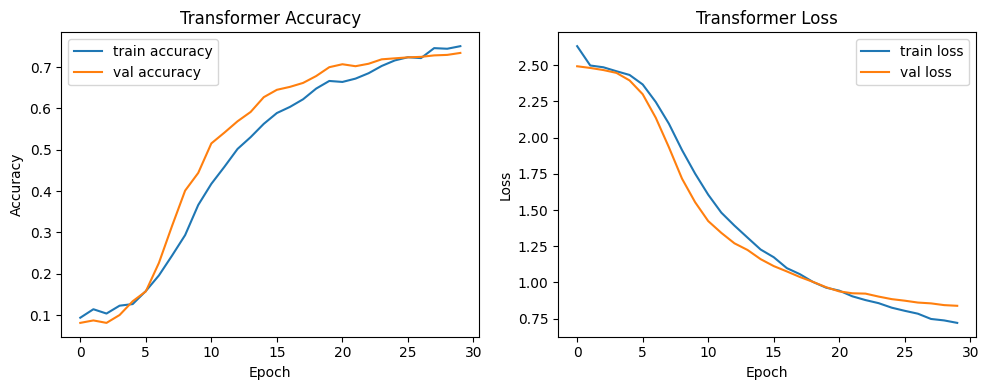

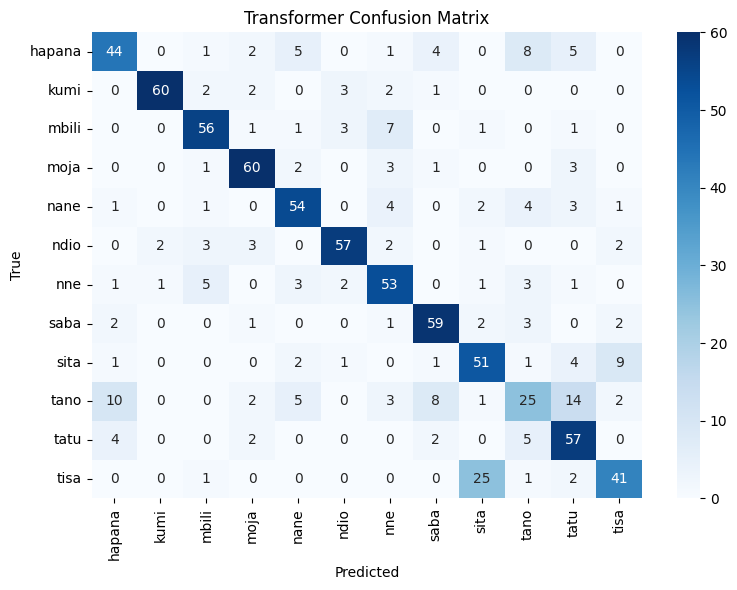

Saved files:
['lstm_learning_curves.png', 'lstm_confusion_matrix.png', 'lstm_misclassified_examples.csv', 'lstm_model.keras', 'results_summary.txt', 'transformer_learning_curves.png', 'transformer_confusion_matrix.png', 'transformer_model.keras']


In [21]:
#now resave the findings
save_dir = '/content/drive/MyDrive/david_lstm_baselines'
os.makedirs(save_dir, exist_ok=True)

# transformer learning curves (overwrites the broken-run version if one was saved)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(transformer_history.history['accuracy'], label='train accuracy')
plt.plot(transformer_history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Transformer Accuracy')

plt.subplot(1, 2, 2)
plt.plot(transformer_history.history['loss'], label='train loss')
plt.plot(transformer_history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Transformer Loss')

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'transformer_learning_curves.png'), dpi=150)
plt.show()

# transformer confusion matrix (overwrites the broken-run version)
cm_transformer = confusion_matrix(y_val, transformer_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_transformer, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Transformer Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'transformer_confusion_matrix.png'), dpi=150)
plt.show()

# save the trained transformer model
transformer_model.save(os.path.join(save_dir, 'transformer_model.keras'))

# update the results summary with all 3 numbers
with open(os.path.join(save_dir, 'results_summary.txt'), 'w') as f:
    f.write("Model Results Summary\n")
    f.write("======================\n")
    f.write(f"Logistic Regression accuracy: {log_reg_acc:.4f}\n")
    f.write(f"Random Forest accuracy: {rf_acc:.4f}\n")
    f.write(f"LSTM accuracy: {lstm_acc:.4f}\n")
    f.write(f"Transformer accuracy: {transformer_acc:.4f}\n")

print("Saved files:")
print(os.listdir(save_dir))